In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
df = pd.read_csv('data offstat.csv')
df = df.dropna(how='all')
df.head()

,Kategori,Nama Kabupaten,Tahun,IKP,IPM (Indeks \nPembangunan Manusia),Kepadatan Penduduk \nper km persegi (Km2),Tingkat Pengangguran Terbuka (TPT) (Persen),Persentase Penduduk Miskin (Persen),Luas Panen \nTanaman Padi \n(ha) (Ha),Produktivitas \nTanaman Padi \n(ku/ha) (Ku/ha),Rekap Produksi \nPadi \n(ton) (Ton),Jumlah bayi Gizi Kurang (Rb),Jumlah bayi (Rb),Prevalensi Bayi Gizi Kurang (%)
0,kabupaten,Pacitan,2025.0,"72,07318","72,26",411.0,"1,4","12,97",26774,"49,49",132516,2476.0,34.24,"7,231308411"
1,kabupaten,Ponorogo,2025.0,"71,21762","74,65",681.0,"3,85","8,86",74200,"58,8",436300,3293.0,61.44,"5,359700521"
2,kabupaten,Trenggalek,2025.0,"76,82007","73,39",598.0,"3,86","10,29",27943,"56,55",158029,2560.0,47.64,"5,3736356"
3,kabupaten,Tulungagung,2025.0,"74,81565","75,88",978.0,"4,03","5,96",39342,"61,15",240566,4230.0,74.36,"5,688542227"
4,kabupaten,Blitar,2025.0,"69,7067","74,43",730.0,"4,49","7,57",35796,"64,65",231437,4914.0,86.33,"5,692111665"


In [ ]:
col_mapping = {
    'Nama Kabupaten': 'Kabupaten/Kota',
    'Tahun': 'Tahun',
    'IPM (Indeks \nPembangunan Manusia)': 'IPM',
    'Persentase Penduduk Miskin  (Persen)': 'Kemiskinan',
    'Tingkat Pengangguran Terbuka (TPT) (Persen)': 'TPT',
    'Kepadatan Penduduk \nper km persegi (Km2)': 'Kepadatan_Penduduk',
    'Prevalensi Bayi Gizi Kurang (%)': 'Prevalensi_Gizi_Kurang'
}
df = df.rename(columns=col_mapping)

# Kolom yang akan dimasukkan ke PCA (IKP tidak dimasukkan)
pca_vars = ['IPM', 'Kemiskinan', 'TPT', 'Kepadatan_Penduduk', 'Prevalensi_Gizi_Kurang']
df_pca = df[['Kabupaten/Kota', 'Tahun'] + pca_vars].dropna()

# Mengubah format desimal koma (,) menjadi titik (.) jika data terbaca sebagai string/object
for col in pca_vars:
    if df_pca[col].dtype == 'object':
        df_pca[col] = df_pca[col].str.replace(',', '.').astype(float)

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca[pca_vars])

## PCA

In [ ]:
pca = PCA()
pca.fit(X_scaled)
scores = pca.transform(X_scaled)

## Eigenvalue dan Proporsi Keragaman

In [ ]:
eigenvalues = pca.explained_variance_
explained_variance_ratio = pca.explained_variance_ratio_ * 100
cumulative_variance = np.cumsum(explained_variance_ratio)

# Membuat Tabel Eigenvalue
df_eigen = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(eigenvalues))],
    'Eigenvalue': eigenvalues,
    'Proportion of Variance (%)': explained_variance_ratio,
    'Cumulative Variance (%)': cumulative_variance
})
print("Tabel Eigenvalue:")
print(df_eigen)
df_eigen.to_csv('Tabel_Eigenvalue.csv', index=False)

# Menambahkan Skor PCA ke dataframe untuk Indeks Kerentanan Wilayah
for i in range(len(pca_vars)):
    df_pca[f'PC{i+1}'] = scores[:, i]

# Menyimpan Skor PCA per kabupaten/kota ke CSV
df_pca.to_csv('Skor_PCA_Kabupaten_Kota.csv', index=False)

Tabel Eigenvalue:
  Principal Component  Eigenvalue  Proportion of Variance (%)  \
0                 PC1    2.788601                   55.478490   
1                 PC2    1.100457                   21.893297   
2                 PC3    0.599626                   11.929398   
3                 PC4    0.409598                    8.148850   
4                 PC5    0.128173                    2.549965   

   Cumulative Variance (%)  
0                55.478490  
1                77.371787  
2                89.301185  
3                97.450035  
4               100.000000  


## Visualisasi

###scree plot

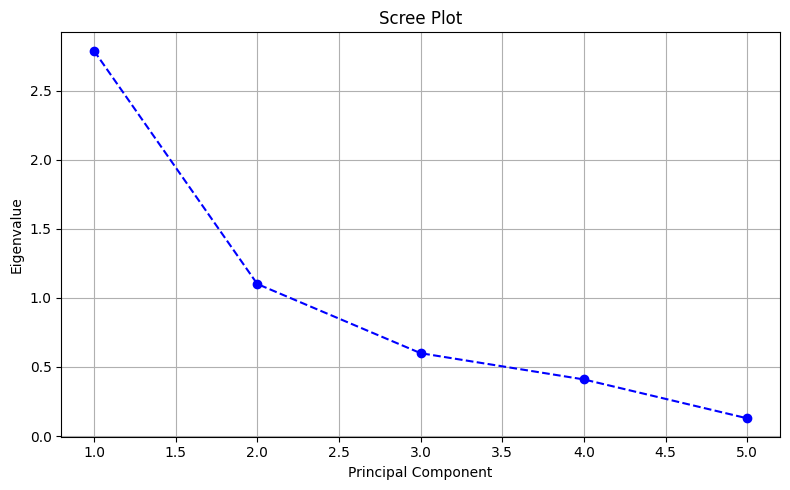

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='o', linestyle='--', color='b')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.grid(True)
plt.tight_layout()
plt.show()

### loading plot

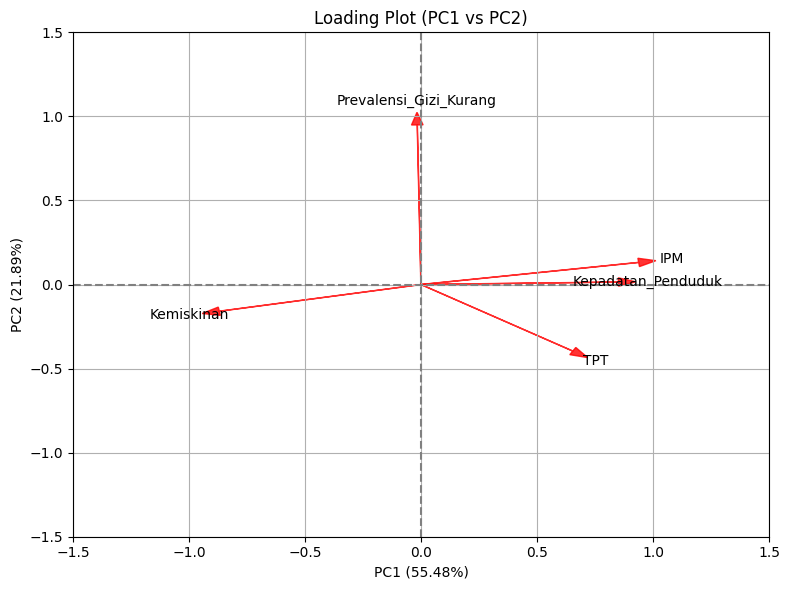

In [ ]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
plt.figure(figsize=(8, 6))
for i, feature in enumerate(pca_vars):
    plt.arrow(0, 0, loadings[i, 0], loadings[i, 1], color='red', alpha=0.8, head_width=0.05)
    plt.text(loadings[i, 0]*1.15, loadings[i, 1]*1.15, feature, color='black', ha='center', va='center')

plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.title('Loading Plot (PC1 vs PC2)')
plt.xlabel(f'PC1 ({explained_variance_ratio[0]:.2f}%)')
plt.ylabel(f'PC2 ({explained_variance_ratio[1]:.2f}%)')
plt.grid(True)
plt.tight_layout()
plt.show()

### biplot

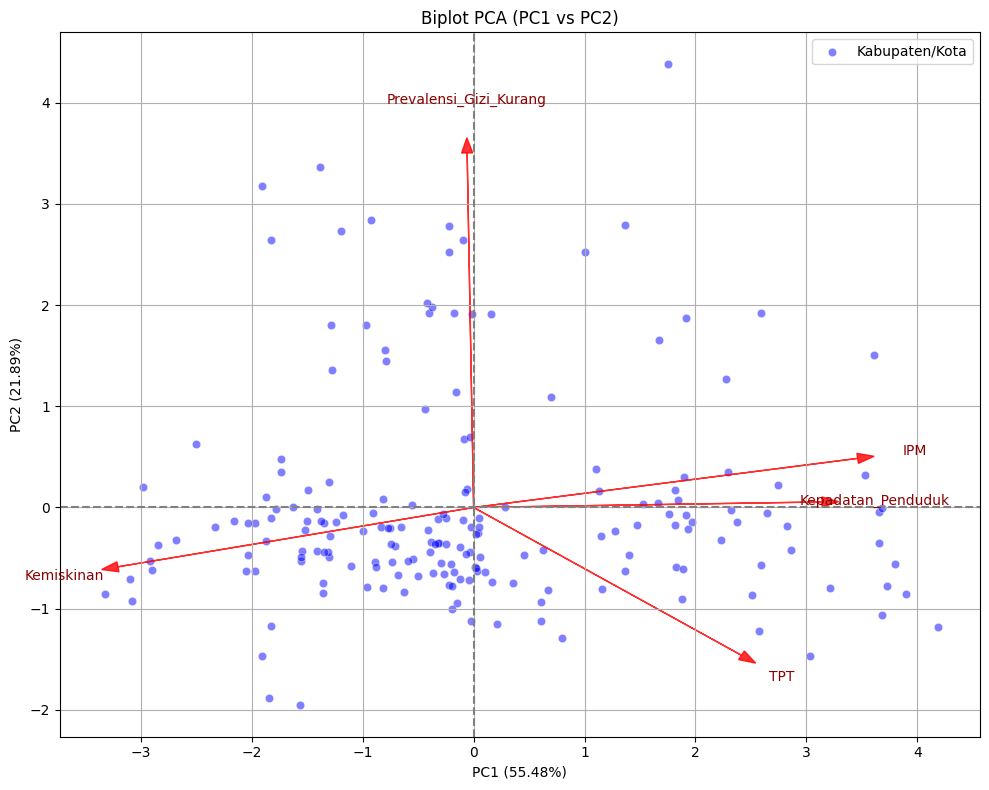

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=scores[:, 0], y=scores[:, 1], alpha=0.5, color='blue', label='Kabupaten/Kota')

scale_factor = np.max(np.abs(scores[:, :2])) / np.max(np.abs(loadings[:, :2])) * 0.8
for i, feature in enumerate(pca_vars):
    plt.arrow(0, 0, loadings[i, 0]*scale_factor, loadings[i, 1]*scale_factor, color='red', alpha=0.8, head_width=0.1)
    plt.text(loadings[i, 0]*scale_factor*1.15, loadings[i, 1]*scale_factor*1.15, feature, color='darkred', ha='center', va='center')

plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.title('Biplot PCA (PC1 vs PC2)')
plt.xlabel(f'PC1 ({explained_variance_ratio[0]:.2f}%)')
plt.ylabel(f'PC2 ({explained_variance_ratio[1]:.2f}%)')
plt.grid(True)
plt.tight_layout()
plt.show()

## PERSIAPAN DAN PENGGABUNGAN DATA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load data skor PCA
df_pca = pd.read_csv('Skor_PCA_Kabupaten_Kota.csv')

# Load data offstat raw untuk mengambil IKP, Produksi, dan Produktivitas
df_raw = pd.read_csv('data offstat.csv')

# Mengganti nama kolom agar bisa di-merge (gabung)
df_raw.rename(columns={'Nama Kabupaten': 'Kabupaten/Kota'}, inplace=True)

# Merge data PCA dan Data Offstat
df_merged = pd.merge(df_pca, df_raw[['Kabupaten/Kota', 'Tahun', 'IKP',
                                     'Rekap Produksi \nPadi \n(ton) (Ton)',
                                     'Produktivitas \nTanaman Padi \n(ku/ha) (Ku/ha)']],
                     on=['Kabupaten/Kota', 'Tahun'], how='left')

# Membersihkan format angka Indonesia (koma menjadi titik) untuk profiling
cols_to_clean = ['IKP', 'Rekap Produksi \nPadi \n(ton) (Ton)', 'Produktivitas \nTanaman Padi \n(ku/ha) (Ku/ha)']
for col in cols_to_clean:
    if df_merged[col].dtype == 'object':
        df_merged[col] = df_merged[col].str.replace(',', '.').astype(float)

## MENENTUKAN JUMLAH CLUSTER (ELBOW & SILHOUETTE)

In [ ]:
# Berdasarkan Tabel Eigenvalue, kita gunakan PC1 dan PC2 (Eigenvalue > 1)
X = df_merged[['PC1', 'PC2']]

# Scaling data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Mencari jumlah k optimal (2 hingga 10)
K = range(2, 11)
inertia = []
silhouette_scores = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

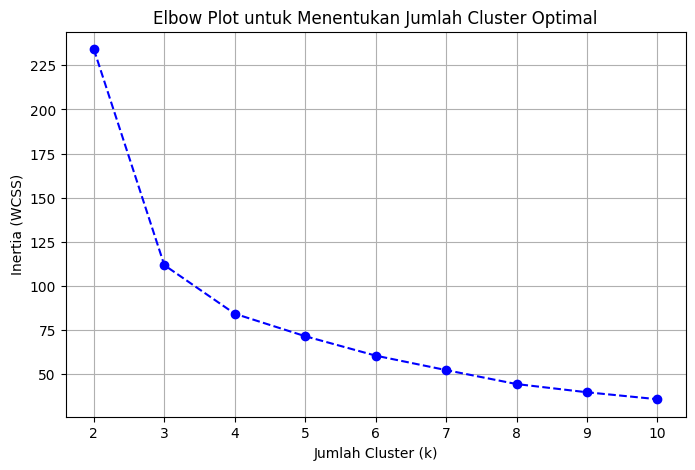

In [ ]:
# Visualisasi Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o', linestyle='--', color='blue')
plt.title('Elbow Plot untuk Menentukan Jumlah Cluster Optimal')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(K)
plt.grid(True)
plt.show()

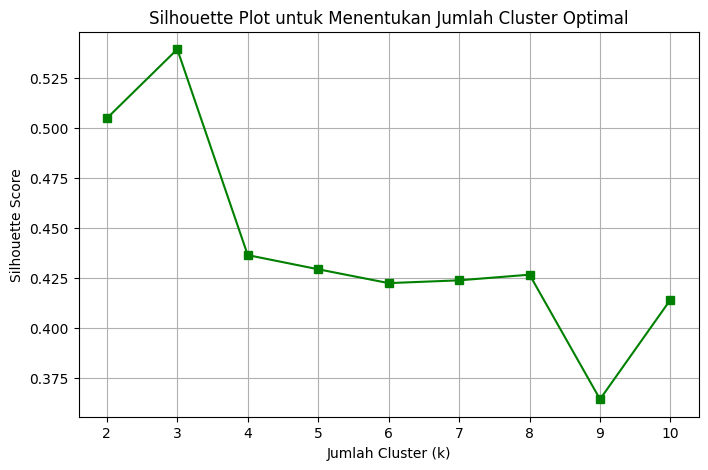

In [ ]:
# Visualisasi Silhouette Score
plt.figure(figsize=(8, 5))
plt.plot(K, silhouette_scores, marker='s', linestyle='-', color='green')
plt.title('Silhouette Plot untuk Menentukan Jumlah Cluster Optimal')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Silhouette Score')
plt.xticks(K)
plt.grid(True)
plt.show()

## K-MEANS CLUSTERING FINAL

In [ ]:
k_optimal = 3

# Menjalankan K-Means dengan jumlah cluster yang sudah dipastikan
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df_merged['Cluster'] = kmeans_final.fit_predict(X_scaled)

# Ubah nama cluster agar mulai dari 1 (misal: Cluster 1, 2, 3) bukan dari 0
df_merged['Cluster'] = df_merged['Cluster'] + 1

# Menampilkan 5 data teratas untuk memastikan cluster sudah masuk ke dataset
print("Preview Hasil Pembagian Cluster:")
display(df_merged[['Kabupaten/Kota', 'Tahun', 'Cluster']].head())

Preview Hasil Pembagian Cluster:


,Kabupaten/Kota,Tahun,Cluster
0,Pacitan,2025.0,2
1,Ponorogo,2025.0,2
2,Trenggalek,2025.0,2
3,Tulungagung,2025.0,2
4,Blitar,2025.0,2


## SCATTERPLOT CLUSTER

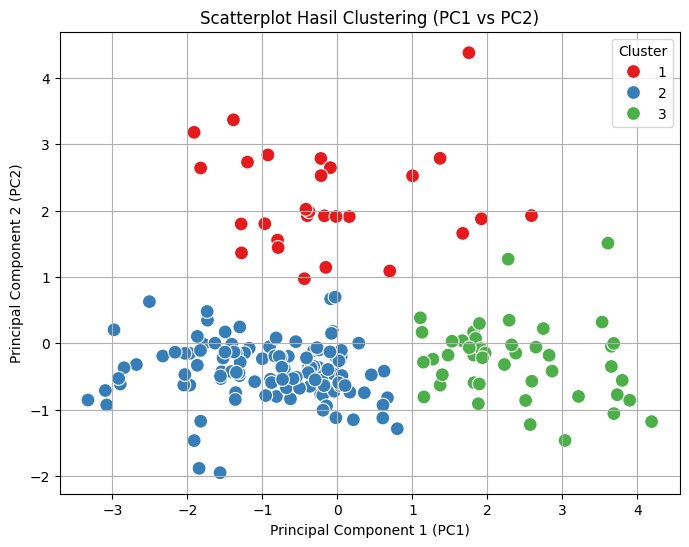

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_merged['PC1'], y=df_merged['PC2'],
                hue=df_merged['Cluster'], palette='Set1', s=100)

plt.title('Scatterplot Hasil Clustering (PC1 vs PC2)')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

## EVALUASI HASIL CLUSTERING (ANALISIS KUALITAS)

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Menghitung Silhouette Score
sil_score = silhouette_score(X_scaled, df_merged['Cluster'])

# Menghitung Inertia (Within-Cluster Sum of Squares)
inertia_val = kmeans_final.inertia_

# Menghitung Davies-Bouldin Index
db_index = davies_bouldin_score(X_scaled, df_merged['Cluster'])

print("=======================================")
print("EVALUASI KUALITAS CLUSTERING")
print("=======================================")
print(f"1. Silhouette Score      : {sil_score:.3f} (Mendekati 1 = Semakin Baik)")
print(f"2. Inertia (WCSS)        : {inertia_val:.3f} (Semakin kecil = Semakin Rapat)")
print(f"3. Davies-Bouldin Index  : {db_index:.3f} (Mendekati 0 = Semakin Baik)")
print("=======================================")

EVALUASI KUALITAS CLUSTERING
1. Silhouette Score      : 0.540 (Mendekati 1 = Semakin Baik)
2. Inertia (WCSS)        : 111.737 (Semakin kecil = Semakin Rapat)
3. Davies-Bouldin Index  : 0.628 (Mendekati 0 = Semakin Baik)


## PROFILING CLUSTER

In [ ]:
profiling_columns = ['IKP', 'Rekap Produksi \nPadi \n(ton) (Ton)',
                     'Produktivitas \nTanaman Padi \n(ku/ha) (Ku/ha)', 'PC1', 'PC2']

# Menghitung rata-rata untuk setiap cluster
cluster_profile = df_merged.groupby('Cluster')[profiling_columns].mean().round(2)

# Menampilkan Profil Cluster
print("=======================================")
print("TABEL KARAKTERISTIK CLUSTER (Rata-Rata)")
print("=======================================")
display(cluster_profile)

TABEL KARAKTERISTIK CLUSTER (Rata-Rata)


,IKP,Rekap Produksi \nPadi \n(ton) (Ton),Produktivitas \nTanaman Padi \n(ku/ha) (Ku/ha),PC1,PC2
Cluster,,,,,
1,71.10,276168.62,58.48,-0.13,2.17
2,78.44,336105.17,55.87,-0.89,-0.42
3,77.04,37300.81,60.09,2.39,-0.25


## EXPORT HASIL CLUSTER

In [ ]:
df_merged.to_excel('hasil_cluster.xlsx', index=False)
print("\n[INFO] Dataset 'hasil_cluster.xlsx' telah berhasil diekspor!")


[INFO] Dataset 'hasil_cluster.xlsx' telah berhasil diekspor!
